<a href="https://colab.research.google.com/github/ANGEL05122002/Estadistica-Bayesiana/blob/main/PRO_BAYESIANA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import unicodedata

In [4]:
df = pd.read_csv("rendimiento_academico_dataset.csv", encoding="latin1")
df.head()

,Sexo,edad,educacion_parental,familia_ingresos,acceso_internet,estudio_medio_ambiente,horas_de_estudio_por_dia,tasa_asistencia,dormir_horas,horas_redes_sociales,...,cursos_en_linea_completados,tutoria,puntuacion_matematica,lectura_puntuacion,escritura_puntuacion,puntuacion_ciencia,puntuacion_examen_final,anterior_gpa,pass_fail,grado_categoria
0,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,0.1,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,2.9,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,2.4,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,3.5,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,2.1,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


In [5]:
def normalize_col(name):
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    return name.strip().lower().replace(" ", "_")

df = df.rename(columns={c: normalize_col(c) for c in df.columns})

print("Columnas del dataset:")
for col in df.columns:
    print(col)

Columnas del dataset:
sexo
edad
educacion_parental
familia_ingresos
acceso_internet
estudio_medio_ambiente
horas_de_estudio_por_dia
tasa_asistencia
dormir_horas
horas_redes_sociales
tasa_de_finalizacion_asignacion
puntuacion_participacion
cursos_en_linea_completados
tutoria
puntuacion_matematica
lectura_puntuacion
escritura_puntuacion
puntuacion_ciencia
puntuacion_examen_final
anterior_gpa
pass_fail
grado_categoria


In [6]:
variables_modelo = [
    "horas_redes_sociales",
    "horas_de_estudio_por_dia",
    "tasa_asistencia",
    "puntuacion_participacion",
    "tasa_de_finalizacion_asignacion",
    "anterior_gpa",
    "puntuacion_examen_final",
    "pass_fail"
]

print("Variables seleccionadas:")
print(variables_modelo)


Variables seleccionadas:
['horas_redes_sociales', 'horas_de_estudio_por_dia', 'tasa_asistencia', 'puntuacion_participacion', 'tasa_de_finalizacion_asignacion', 'anterior_gpa', 'puntuacion_examen_final', 'pass_fail']

¿Existen en la base?
horas_redes_sociales -> True
horas_de_estudio_por_dia -> True
tasa_asistencia -> True
puntuacion_participacion -> True
tasa_de_finalizacion_asignacion -> True
anterior_gpa -> True
puntuacion_examen_final -> True
pass_fail -> True


In [7]:
df_modelo = df[variables_modelo].copy()
df_modelo.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final,pass_fail
0,0.1,2.98,96.5,68.7,80.5,2.44,49.1,Fail
1,2.9,4.45,95.7,92.6,70.9,2.79,70.1,Pass
2,2.4,3.75,76.0,45.8,77.6,1.49,42.2,Fail
3,3.5,2.03,72.6,72.9,63.5,1.34,31.9,Fail
4,2.1,5.14,87.3,55.7,71.8,2.60,66.4,Pass


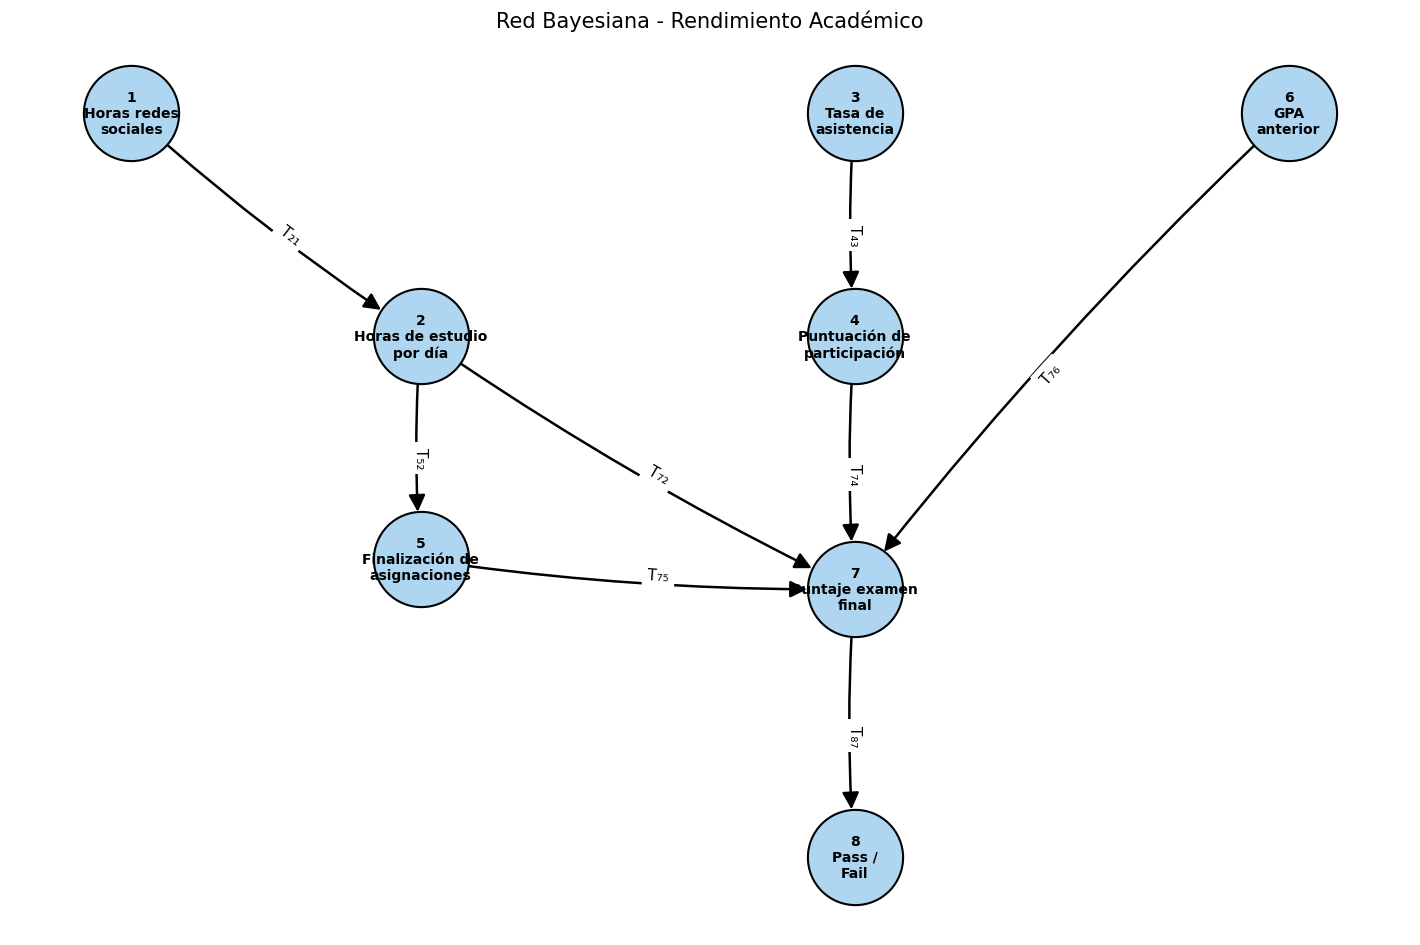

In [8]:
edges = [
    ("horas_redes_sociales", "horas_de_estudio_por_dia"),
    ("tasa_asistencia", "puntuacion_participacion"),
    ("horas_de_estudio_por_dia", "tasa_de_finalizacion_asignacion"),
    ("horas_de_estudio_por_dia", "puntuacion_examen_final"),
    ("puntuacion_participacion", "puntuacion_examen_final"),
    ("tasa_de_finalizacion_asignacion", "puntuacion_examen_final"),
    ("anterior_gpa", "puntuacion_examen_final"),
    ("puntuacion_examen_final", "pass_fail")
]

G = nx.DiGraph()
G.add_edges_from(edges)

pos = {
    "horas_redes_sociales": (-4, 4),
    "horas_de_estudio_por_dia": (-2, 2.5),
    "tasa_asistencia": (1, 4),
    "puntuacion_participacion": (1, 2.5),
    "tasa_de_finalizacion_asignacion": (-2, 1),
    "anterior_gpa": (4, 4),
    "puntuacion_examen_final": (1, 0.8),
    "pass_fail": (1, -1)
}

labels = {
    "horas_redes_sociales": "1\nHoras redes\nsociales",
    "horas_de_estudio_por_dia": "2\nHoras de estudio\npor día",
    "tasa_asistencia": "3\nTasa de\nasistencia",
    "puntuacion_participacion": "4\nPuntuación de\nparticipación",
    "tasa_de_finalizacion_asignacion": "5\nFinalización de\nasignaciones",
    "anterior_gpa": "6\nGPA\nanterior",
    "puntuacion_examen_final": "7\nPuntaje examen\nfinal",
    "pass_fail": "8\nPass /\nFail"
}

edge_labels = {
    ("horas_redes_sociales", "horas_de_estudio_por_dia"): "T₂₁",
    ("tasa_asistencia", "puntuacion_participacion"): "T₄₃",
    ("horas_de_estudio_por_dia", "tasa_de_finalizacion_asignacion"): "T₅₂",
    ("horas_de_estudio_por_dia", "puntuacion_examen_final"): "T₇₂",
    ("puntuacion_participacion", "puntuacion_examen_final"): "T₇₄",
    ("tasa_de_finalizacion_asignacion", "puntuacion_examen_final"): "T₇₅",
    ("anterior_gpa", "puntuacion_examen_final"): "T₇₆",
    ("puntuacion_examen_final", "pass_fail"): "T₈₇"
}

plt.figure(figsize=(14, 9))

nx.draw(
    G, pos,
    with_labels=False,
    node_size=4700,
    node_color="#AED6F1",
    edgecolors="black",
    linewidths=1.5,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=25,
    width=1.8,
    connectionstyle='arc3,rad=0.04'
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=11,
    bbox=dict(facecolor='white', edgecolor='none'),
    label_pos=0.55
)

plt.title("Red Bayesiana - Rendimiento Académico", fontsize=15)
plt.axis("off")
plt.show()

In [12]:
df_modelo.describe(include="all")

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final,pass_fail
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fail
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1261
mean,2.478160,3.056400,84.766160,69.947440,79.586840,1.998676,49.971240,NaN
std,1.429214,1.178868,9.332483,14.629129,13.824584,0.553003,12.225455,NaN
min,0.000000,0.500000,51.800000,23.500000,40.000000,0.000000,8.000000,NaN
25%,1.400000,2.250000,78.500000,60.200000,70.000000,1.617500,42.000000,NaN
50%,2.400000,3.050000,85.100000,70.050000,80.300000,2.000000,49.800000,NaN
75%,3.400000,3.872500,91.400000,80.100000,90.300000,2.370000,58.100000,NaN


In [13]:
variables_continuas = [
    "horas_redes_sociales",
    "horas_de_estudio_por_dia",
    "tasa_asistencia",
    "puntuacion_participacion",
    "tasa_de_finalizacion_asignacion",
    "anterior_gpa",
    "puntuacion_examen_final"
]

variable_final = "pass_fail"

print("Continuas:", variables_continuas)
print("Final discreta:", variable_final)

Continuas: ['horas_redes_sociales', 'horas_de_estudio_por_dia', 'tasa_asistencia', 'puntuacion_participacion', 'tasa_de_finalizacion_asignacion', 'anterior_gpa', 'puntuacion_examen_final']
Final discreta: pass_fail


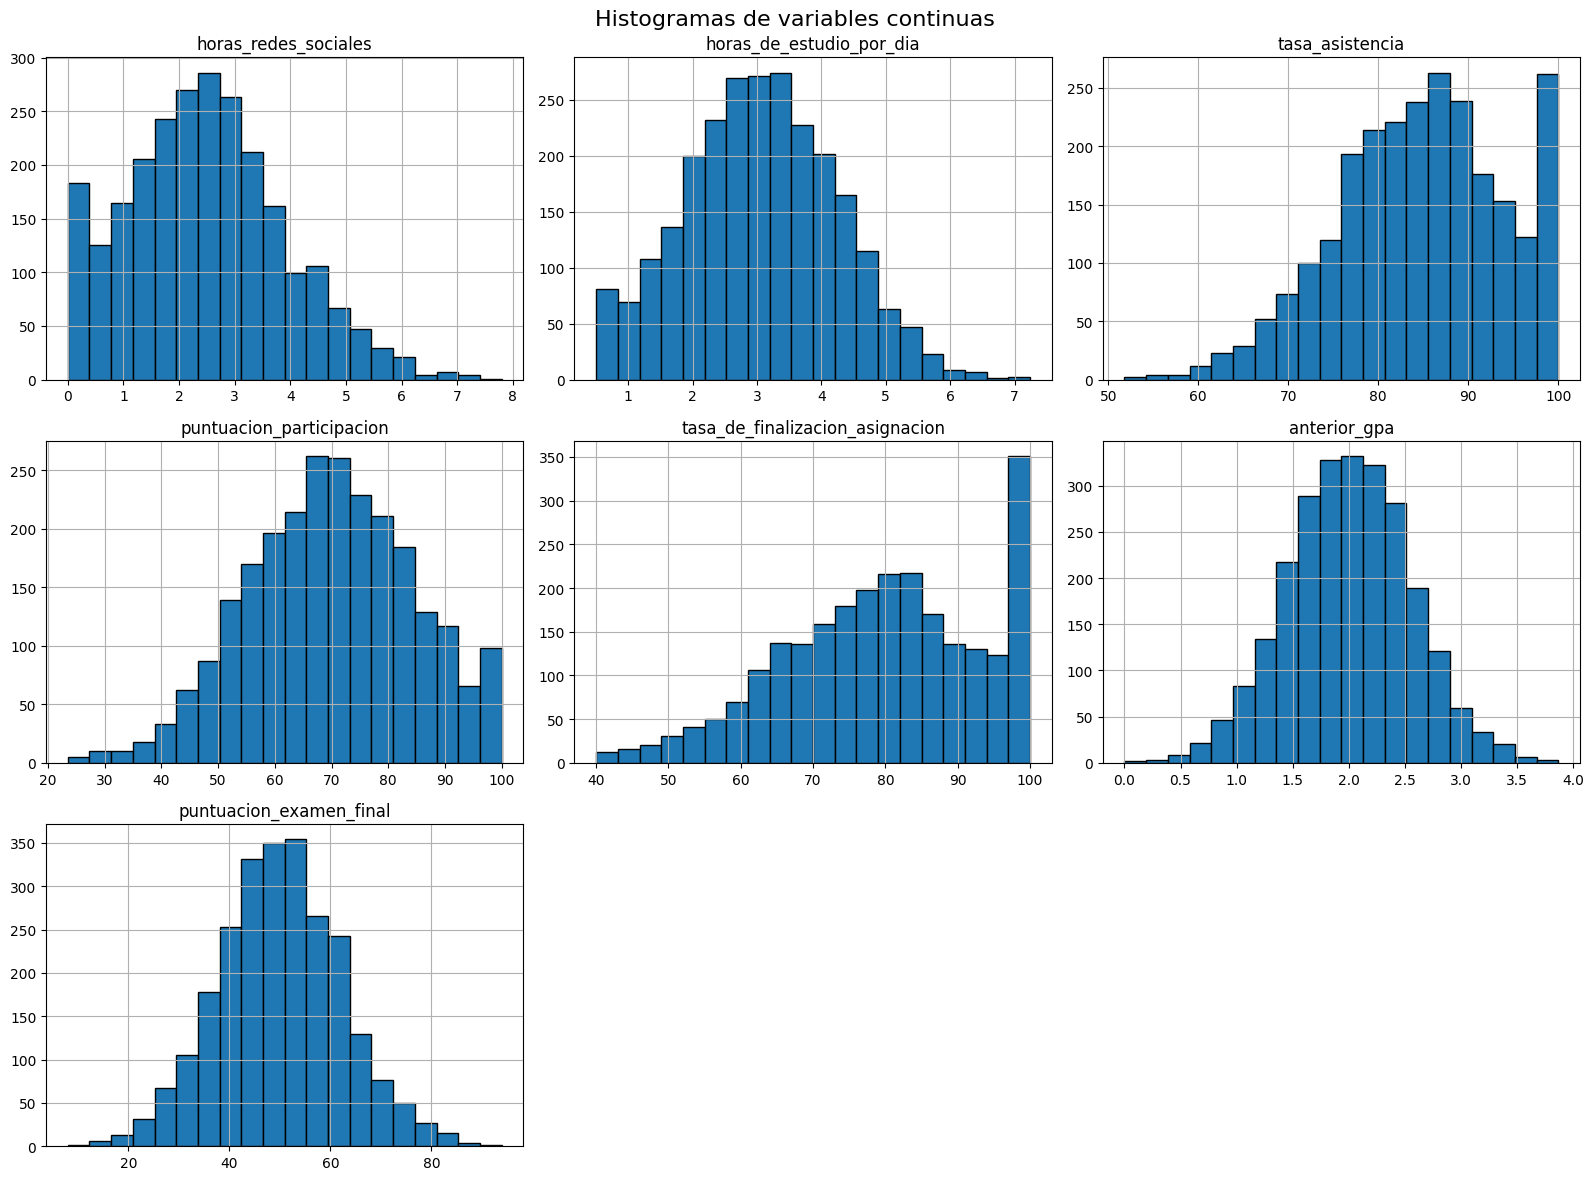

In [14]:
df_modelo[variables_continuas].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Histogramas de variables continuas", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
percentiles = df_modelo[variables_continuas].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentiles.columns = ["q10", "q25", "q50", "q75", "q90"]
percentiles

,q10,q25,q50,q75,q90
horas_redes_sociales,0.600,1.4000,2.40,3.4000,4.40
horas_de_estudio_por_dia,1.499,2.2500,3.05,3.8725,4.58
tasa_asistencia,72.300,78.5000,85.10,91.4000,97.80
puntuacion_participacion,50.890,60.2000,70.05,80.1000,89.50
tasa_de_finalizacion_asignacion,61.390,70.0000,80.30,90.3000,100.00
anterior_gpa,1.299,1.6175,2.00,2.3700,2.70
puntuacion_examen_final,34.890,42.0000,49.80,58.1000,65.30


In [16]:
corr_spearman = df_modelo[variables_continuas].corr(method="spearman")
corr_spearman

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
horas_redes_sociales,1.000000,-0.008789,-0.003824,0.006380,-0.060732,-0.241068,-0.270071
horas_de_estudio_por_dia,-0.008789,1.000000,0.026758,0.031119,-0.026083,0.514606,0.578612
tasa_asistencia,-0.003824,0.026758,1.000000,0.014816,0.026702,0.143897,0.163333
puntuacion_participacion,0.006380,0.031119,0.014816,1.000000,-0.020242,0.118876,0.150668
tasa_de_finalizacion_asignacion,-0.060732,-0.026083,0.026702,-0.020242,1.000000,0.146411,0.171807
anterior_gpa,-0.241068,0.514606,0.143897,0.118876,0.146411,1.000000,0.882865
puntuacion_examen_final,-0.270071,0.578612,0.163333,0.150668,0.171807,0.882865,1.000000


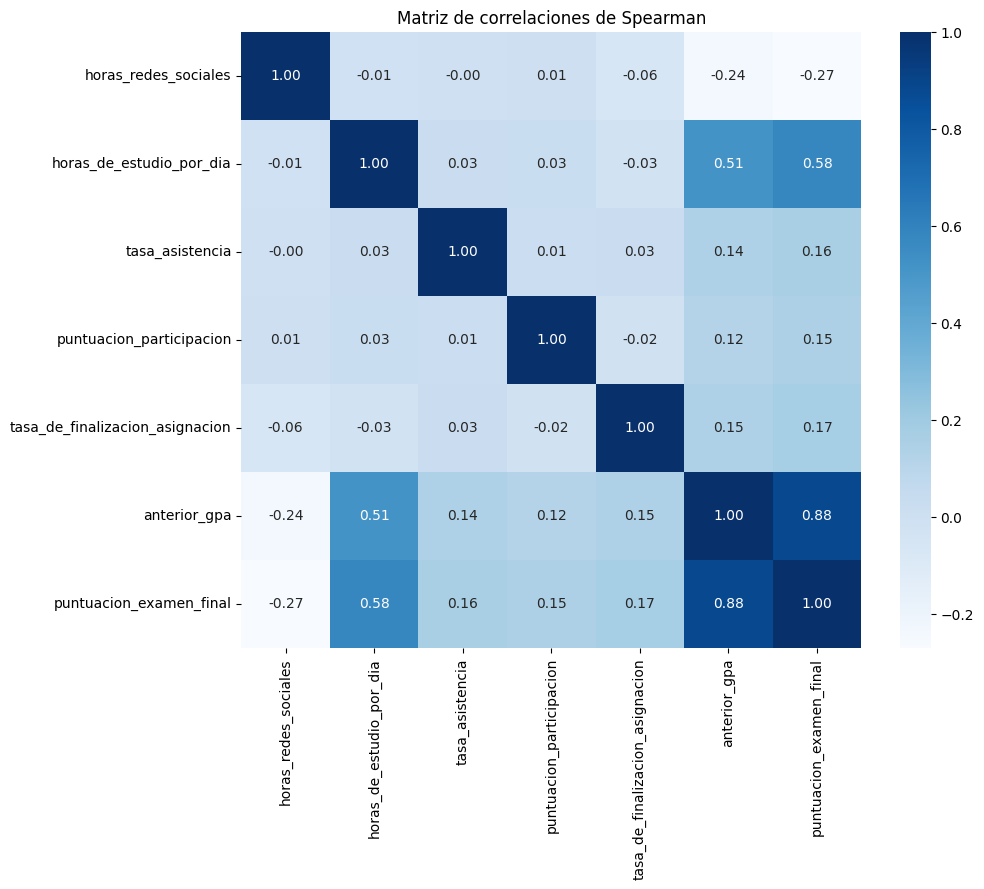

In [17]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlaciones de Spearman")
plt.show()

In [18]:
pd.crosstab(df_modelo["pass_fail"], df_modelo["puntuacion_examen_final"] >= 50)

puntuacion_examen_final,False,True
pass_fail,,
Fail,1261,0
Pass,0,1239


In [19]:
df_modelo.groupby("pass_fail")["puntuacion_examen_final"].describe()

,count,mean,std,min,25%,50%,75%,max
pass_fail,,,,,,,,
Fail,1261.0,40.375971,7.286331,8.0,36.3,42.1,46.0,49.9
Pass,1239.0,59.736885,7.644716,50.0,53.5,58.2,63.8,93.9


In [20]:
from scipy import stats

In [21]:
bounds = {
    "horas_redes_sociales": (0, 8),
    "horas_de_estudio_por_dia": (0, 8),
    "tasa_asistencia": (0, 100),
    "puntuacion_participacion": (0, 100),
    "tasa_de_finalizacion_asignacion": (0, 100),
    "anterior_gpa": (0, 4),
    "puntuacion_examen_final": (0, 100),
}

In [22]:
def fit_scaled_beta(x, lower, upper):
    eps = 1e-6
    y = (np.asarray(x) - lower) / (upper - lower)
    y = np.clip(y, eps, 1 - eps)

    a, b, loc, scale = stats.beta.fit(y, floc=0, fscale=1)
    ll = np.sum(stats.beta.logpdf(y, a, b, loc=0, scale=1)) - len(y) * np.log(upper - lower)

    k = 2
    aic = 2 * k - 2 * ll
    bic = np.log(len(y)) * k - 2 * ll

    return {
        "distribucion": "beta_escalada",
        "param_1": a,
        "param_2": b,
        "aic": aic,
        "bic": bic
    }

def fit_norm(x):
    x = np.asarray(x)
    mu, sigma = stats.norm.fit(x)
    ll = np.sum(stats.norm.logpdf(x, mu, sigma))

    k = 2
    aic = 2 * k - 2 * ll
    bic = np.log(len(x)) * k - 2 * ll

    return {
        "distribucion": "normal",
        "param_1": mu,
        "param_2": sigma,
        "aic": aic,
        "bic": bic
    }

def fit_gamma(x):
    x = np.asarray(x)
    if np.any(x <= 0):
        return None

    shape, loc, scale = stats.gamma.fit(x, floc=0)
    ll = np.sum(stats.gamma.logpdf(x, shape, loc=0, scale=scale))

    k = 2
    aic = 2 * k - 2 * ll
    bic = np.log(len(x)) * k - 2 * ll

    return {
        "distribucion": "gamma",
        "param_1": shape,
        "param_2": scale,
        "aic": aic,
        "bic": bic
    }

In [23]:
resultados_marginales = []

for col in variables_continuas:
    x = df_modelo[col].dropna().values
    lower, upper = bounds[col]

    candidatos = [
        fit_scaled_beta(x, lower, upper),
        fit_norm(x),
        fit_gamma(x)
    ]

    candidatos = [c for c in candidatos if c is not None]
    mejor = min(candidatos, key=lambda z: z["aic"])

    resultados_marginales.append({
        "variable": col,
        "mejor_distribucion": mejor["distribucion"],
        "param_1": mejor["param_1"],
        "param_2": mejor["param_2"],
        "AIC": mejor["aic"],
        "BIC": mejor["bic"]
    })

tabla_marginales = pd.DataFrame(resultados_marginales)
tabla_marginales

,variable,mejor_distribucion,param_1,param_2,AIC,BIC
0,horas_redes_sociales,beta_escalada,0.686852,1.797843,8644.419831,8656.067923
1,horas_de_estudio_por_dia,normal,3.056400,1.178632,7920.466845,7932.114937
2,tasa_asistencia,beta_escalada,3.758278,0.614175,17878.150577,17889.798669
3,puntuacion_participacion,normal,69.947440,14.626203,20512.765794,20524.413887
4,tasa_de_finalizacion_asignacion,beta_escalada,2.097583,0.454935,18319.516783,18331.164875
5,anterior_gpa,normal,1.998676,0.552892,4135.731027,4147.379120
6,puntuacion_examen_final,normal,49.971240,12.223010,19615.293928,19626.942020


In [24]:
def to_uniform(series, row):
    x = series.values

    if row["mejor_distribucion"] == "normal":
        u = stats.norm.cdf(x, loc=row["param_1"], scale=row["param_2"])

    elif row["mejor_distribucion"] == "gamma":
        u = stats.gamma.cdf(x, a=row["param_1"], loc=0, scale=row["param_2"])

    elif row["mejor_distribucion"] == "beta_escalada":
        lower, upper = bounds[series.name]
        y = (x - lower) / (upper - lower)
        y = np.clip(y, 1e-6, 1 - 1e-6)
        u = stats.beta.cdf(y, a=row["param_1"], b=row["param_2"], loc=0, scale=1)

    else:
        raise ValueError("Distribución no soportada")

    return pd.Series(u, index=series.index, name=series.name)

In [25]:
uniform_df = pd.DataFrame()

for _, row in tabla_marginales.iterrows():
    var = row["variable"]
    uniform_df[var] = to_uniform(df_modelo[var], row)

uniform_df.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
0,0.076557,0.474158,0.699687,0.466016,0.338386,0.787626,0.471588
1,0.682786,0.881474,0.662058,0.939281,0.233809,0.923820,0.950200
2,0.614097,0.721894,0.207758,0.049372,0.302726,0.178779,0.262457
3,0.754048,0.191921,0.169749,0.579990,0.174048,0.116762,0.069642
4,0.568170,0.961454,0.397940,0.165002,0.242140,0.861614,0.910539


In [26]:
uniform_df.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_redes_sociales,2500.0,0.577110,0.230572,0.000118,0.443861,0.614097,0.742943,0.999211
horas_de_estudio_por_dia,2500.0,0.499044,0.291773,0.015043,0.246930,0.497834,0.755659,0.999807
tasa_asistencia,2500.0,0.410202,0.236732,0.041488,0.240355,0.350858,0.505460,0.999496
puntuacion_participacion,2500.0,0.501906,0.292062,0.000748,0.252566,0.502797,0.756201,0.980046
tasa_de_finalizacion_asignacion,2500.0,0.407346,0.254177,0.056572,0.225731,0.335790,0.501255,0.997221
anterior_gpa,2500.0,0.500562,0.288446,0.000150,0.245286,0.500955,0.749082,0.999644
puntuacion_examen_final,2500.0,0.498262,0.286864,0.000298,0.257152,0.494411,0.746987,0.999837


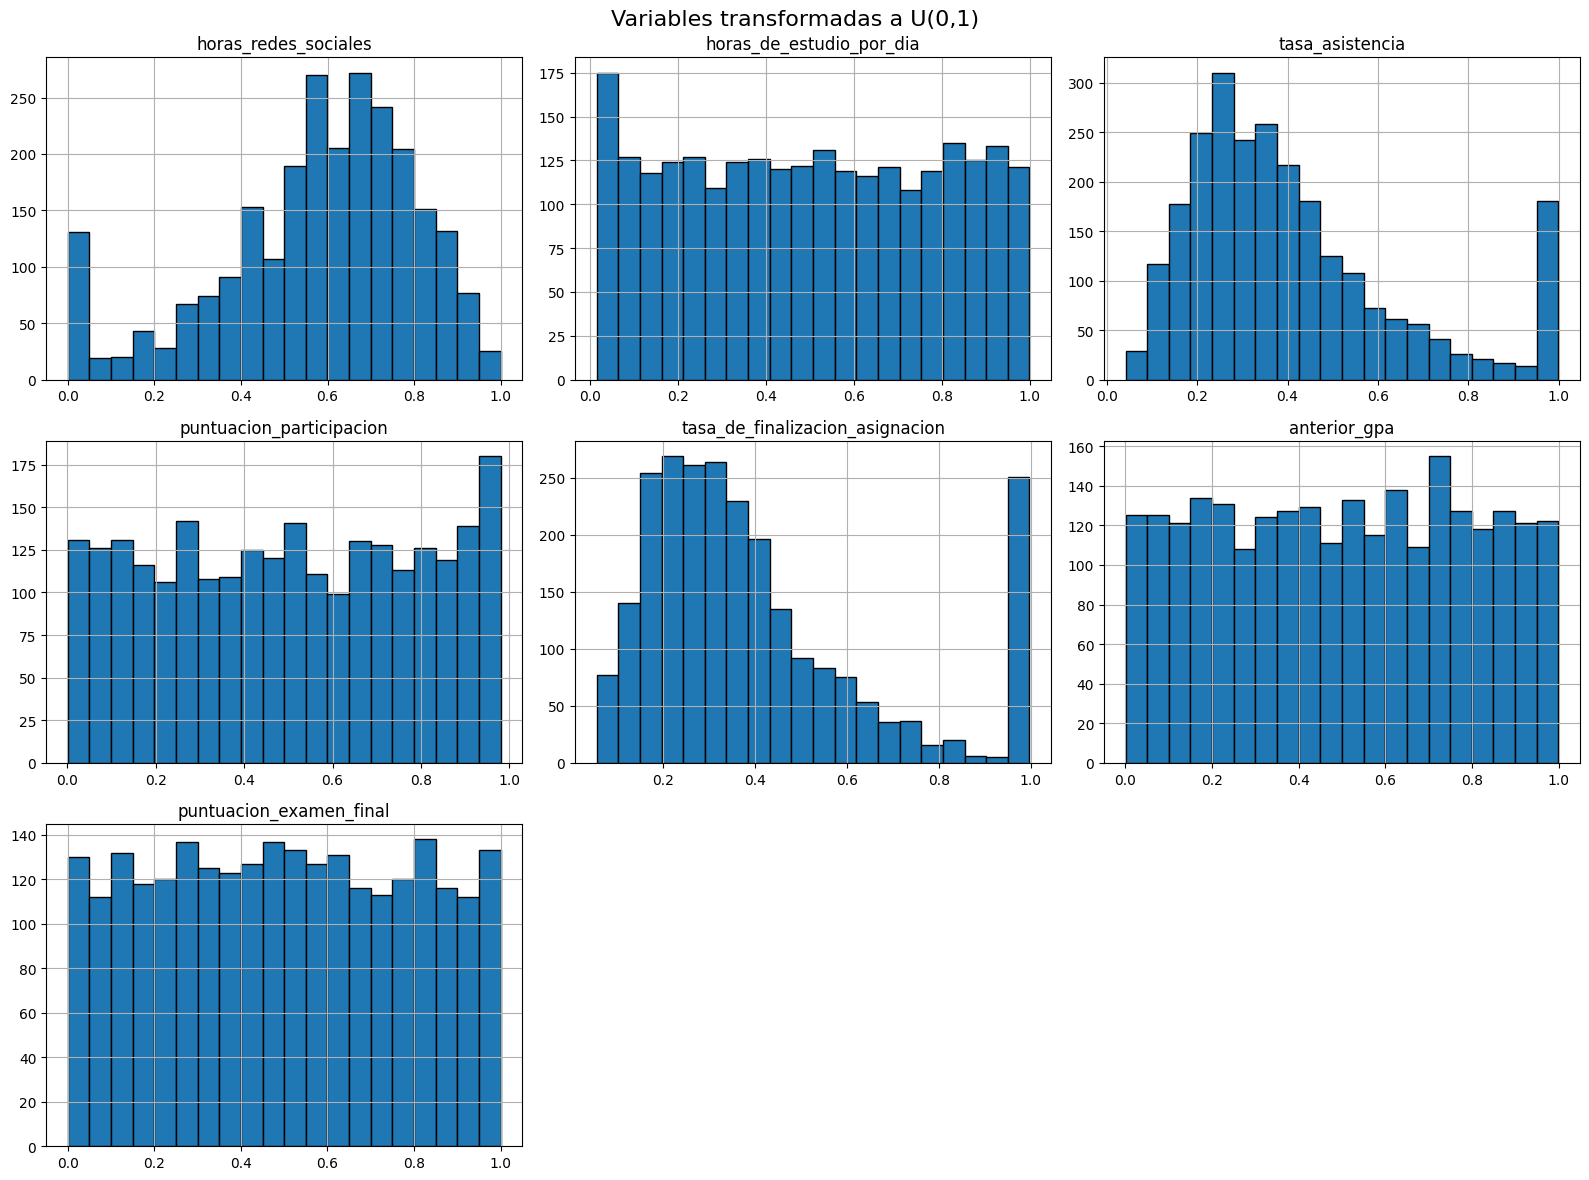

In [27]:
uniform_df.hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Variables transformadas a U(0,1)", fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
corr_uniform = uniform_df.corr(method="spearman")
corr_uniform

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
horas_redes_sociales,1.000000,-0.008789,-0.003824,0.006380,-0.060732,-0.241068,-0.270071
horas_de_estudio_por_dia,-0.008789,1.000000,0.026758,0.031119,-0.026083,0.514606,0.578612
tasa_asistencia,-0.003824,0.026758,1.000000,0.014816,0.026702,0.143897,0.163333
puntuacion_participacion,0.006380,0.031119,0.014816,1.000000,-0.020242,0.118876,0.150668
tasa_de_finalizacion_asignacion,-0.060732,-0.026083,0.026702,-0.020242,1.000000,0.146411,0.171807
anterior_gpa,-0.241068,0.514606,0.143897,0.118876,0.146411,1.000000,0.882865
puntuacion_examen_final,-0.270071,0.578612,0.163333,0.150668,0.171807,0.882865,1.000000


In [29]:
factorizacion = """
P(1,2,3,4,5,6,7,8)
= P(1) P(2|1) P(3) P(4|3) P(5|2) P(6) P(7|2,4,5,6) P(8|7)
"""

print("Factorización de la distribución conjunta:")
print(factorizacion)

Factorización de la distribución conjunta:

P(1,2,3,4,5,6,7,8)
= P(1) P(2|1) P(3) P(4|3) P(5|2) P(6) P(7|2,4,5,6) P(8|7)



In [30]:
CK_IK = {
    2: {"CK": [1], "IK": []},
    4: {"CK": [3], "IK": [1, 2]},
    5: {"CK": [2], "IK": [1, 3, 4]},
    7: {"CK": [2, 4, 5, 6], "IK": [1, 3]},
    8: {"CK": [7], "IK": [1, 2, 3, 4, 5, 6]},
}

for k, vals in CK_IK.items():
    print(f"K = {k}")
    print("  CK =", vals["CK"])
    print("  IK =", vals["IK"])

K = 2
  CK = [1]
  IK = []
K = 4
  CK = [3]
  IK = [1, 2]
K = 5
  CK = [2]
  IK = [1, 3, 4]
K = 7
  CK = [2, 4, 5, 6]
  IK = [1, 3]
K = 8
  CK = [7]
  IK = [1, 2, 3, 4, 5, 6]


In [32]:
orden_muestreo = {
    1: "horas_redes_sociales",
    2: "horas_de_estudio_por_dia",
    3: "tasa_asistencia",
    4: "puntuacion_participacion",
    5: "tasa_de_finalizacion_asignacion",
    6: "anterior_gpa",
    7: "puntuacion_examen_final",
    8: "pass_fail"
}

print("Orden de muestreo:")
for k, v in orden_muestreo.items():
    print(f"{k} -> {v}")

Orden de muestreo:
1 -> horas_redes_sociales
2 -> horas_de_estudio_por_dia
3 -> tasa_asistencia
4 -> puntuacion_participacion
5 -> tasa_de_finalizacion_asignacion
6 -> anterior_gpa
7 -> puntuacion_examen_final
8 -> pass_fail


In [33]:
for k, vals in CK_IK.items():
    ck_names = [orden_muestreo[i] for i in vals["CK"]]
    ik_names = [orden_muestreo[i] for i in vals["IK"]]

    print(f"K = {k} ({orden_muestreo[k]})")
    print("  CK =", ck_names)
    print("  IK =", ik_names)
    print()

K = 2 (horas_de_estudio_por_dia)
  CK = ['horas_redes_sociales']
  IK = []

K = 4 (puntuacion_participacion)
  CK = ['tasa_asistencia']
  IK = ['horas_redes_sociales', 'horas_de_estudio_por_dia']

K = 5 (tasa_de_finalizacion_asignacion)
  CK = ['horas_de_estudio_por_dia']
  IK = ['horas_redes_sociales', 'tasa_asistencia', 'puntuacion_participacion']

K = 7 (puntuacion_examen_final)
  CK = ['horas_de_estudio_por_dia', 'puntuacion_participacion', 'tasa_de_finalizacion_asignacion', 'anterior_gpa']
  IK = ['horas_redes_sociales', 'tasa_asistencia']

K = 8 (pass_fail)
  CK = ['puntuacion_examen_final']
  IK = ['horas_redes_sociales', 'horas_de_estudio_por_dia', 'tasa_asistencia', 'puntuacion_participacion', 'tasa_de_finalizacion_asignacion', 'anterior_gpa']



In [34]:
correlaciones_necesarias = [
    "r21",
    "r43",
    "r52",
    "r76",
    "r75|6",
    "r74|5,6",
    "r72|4,5,6"
]

print("Correlaciones de rango principales del modelo:")
for r in correlaciones_necesarias:
    print("-", r)

Correlaciones de rango principales del modelo:
- r21
- r43
- r52
- r76
- r75|6
- r74|5,6
- r72|4,5,6


In [35]:
pares_iniciales = [
    ("horas_de_estudio_por_dia", "horas_redes_sociales"),
    ("puntuacion_participacion", "tasa_asistencia"),
    ("tasa_de_finalizacion_asignacion", "horas_de_estudio_por_dia"),
    ("puntuacion_examen_final", "anterior_gpa"),
    ("puntuacion_examen_final", "tasa_de_finalizacion_asignacion"),
    ("puntuacion_examen_final", "puntuacion_participacion"),
    ("puntuacion_examen_final", "horas_de_estudio_por_dia")
]

for a, b in pares_iniciales:
    rho = df_modelo[[a, b]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman({a}, {b}) = {rho:.4f}")

Spearman(horas_de_estudio_por_dia, horas_redes_sociales) = -0.0088
Spearman(puntuacion_participacion, tasa_asistencia) = 0.0148
Spearman(tasa_de_finalizacion_asignacion, horas_de_estudio_por_dia) = -0.0261
Spearman(puntuacion_examen_final, anterior_gpa) = 0.8829
Spearman(puntuacion_examen_final, tasa_de_finalizacion_asignacion) = 0.1718
Spearman(puntuacion_examen_final, puntuacion_participacion) = 0.1507
Spearman(puntuacion_examen_final, horas_de_estudio_por_dia) = 0.5786


In [36]:
from scipy.stats import rankdata
from sklearn.linear_model import LinearRegression
import numpy as np

def partial_spearman(df, x, y, controls):
    ranked = df[[x, y] + controls].dropna().copy()
    for col in ranked.columns:
        ranked[col] = rankdata(ranked[col])

    X_controls = ranked[controls].values

    model_x = LinearRegression().fit(X_controls, ranked[x].values)
    resid_x = ranked[x].values - model_x.predict(X_controls)

    model_y = LinearRegression().fit(X_controls, ranked[y].values)
    resid_y = ranked[y].values - model_y.predict(X_controls)

    return np.corrcoef(resid_x, resid_y)[0, 1]

In [37]:
r76 = df_modelo[["puntuacion_examen_final", "anterior_gpa"]].corr(method="spearman").iloc[0, 1]
r75_6 = partial_spearman(df_modelo, "puntuacion_examen_final", "tasa_de_finalizacion_asignacion", ["anterior_gpa"])
r74_56 = partial_spearman(df_modelo, "puntuacion_examen_final", "puntuacion_participacion", ["tasa_de_finalizacion_asignacion", "anterior_gpa"])
r72_456 = partial_spearman(df_modelo, "puntuacion_examen_final", "horas_de_estudio_por_dia", ["puntuacion_participacion", "tasa_de_finalizacion_asignacion", "anterior_gpa"])

print(f"r76      = {r76:.4f}")
print(f"r75|6    = {r75_6:.4f}")
print(f"r74|5,6  = {r74_56:.4f}")
print(f"r72|4,5,6= {r72_456:.4f}")

r76      = 0.8829
r75|6    = 0.0916
r74|5,6  = 0.1021
r72|4,5,6= 0.3294


In [38]:
tabla_rangos = pd.DataFrame({
    "correlacion": ["r21", "r43", "r52", "r76", "r75|6", "r74|5,6", "r72|4,5,6"],
    "valor": [
        df_modelo[["horas_de_estudio_por_dia", "horas_redes_sociales"]].corr(method="spearman").iloc[0,1],
        df_modelo[["puntuacion_participacion", "tasa_asistencia"]].corr(method="spearman").iloc[0,1],
        df_modelo[["tasa_de_finalizacion_asignacion", "horas_de_estudio_por_dia"]].corr(method="spearman").iloc[0,1],
        r76,
        r75_6,
        r74_56,
        r72_456
    ]
})

tabla_rangos

,correlacion,valor
0,r21,-0.008789
1,r43,0.014816
2,r52,-0.026083
3,r76,0.882865
4,r75|6,0.091583
5,"r74|5,6",0.102055
6,"r72|4,5,6",0.329356


In [39]:
pd.crosstab(df_modelo["pass_fail"], df_modelo["puntuacion_examen_final"] >= 50, margins=True)

puntuacion_examen_final,False,True,All
pass_fail,,,
Fail,1261,0,1261
Pass,0,1239,1239
All,1261,1239,2500


In [40]:
df_modelo.groupby("pass_fail")["puntuacion_examen_final"].describe()

,count,mean,std,min,25%,50%,75%,max
pass_fail,,,,,,,,
Fail,1261.0,40.375971,7.286331,8.0,36.3,42.1,46.0,49.9
Pass,1239.0,59.736885,7.644716,50.0,53.5,58.2,63.8,93.9


In [41]:
from sklearn.linear_model import LogisticRegression

df_log = df_modelo.copy()
df_log["pass_fail_num"] = (df_log["pass_fail"].astype(str).str.lower() == "pass").astype(int)

X = df_log[["puntuacion_examen_final"]].values
y = df_log["pass_fail_num"].values

modelo_log = LogisticRegression()
modelo_log.fit(X, y)

print("Intercepto:", modelo_log.intercept_[0])
print("Coeficiente:", modelo_log.coef_[0,0])

Intercepto: -256.9485325716899
Coeficiente: 5.145323912172413


In [42]:
for score in [40, 50, 60, 70, 80]:
    p = modelo_log.predict_proba([[score]])[0,1]
    print(f"P(Pass | puntuacion_examen_final={score}) = {p:.4f}")

P(Pass | puntuacion_examen_final=40) = 0.0000
P(Pass | puntuacion_examen_final=50) = 0.5788
P(Pass | puntuacion_examen_final=60) = 1.0000
P(Pass | puntuacion_examen_final=70) = 1.0000
P(Pass | puntuacion_examen_final=80) = 1.0000


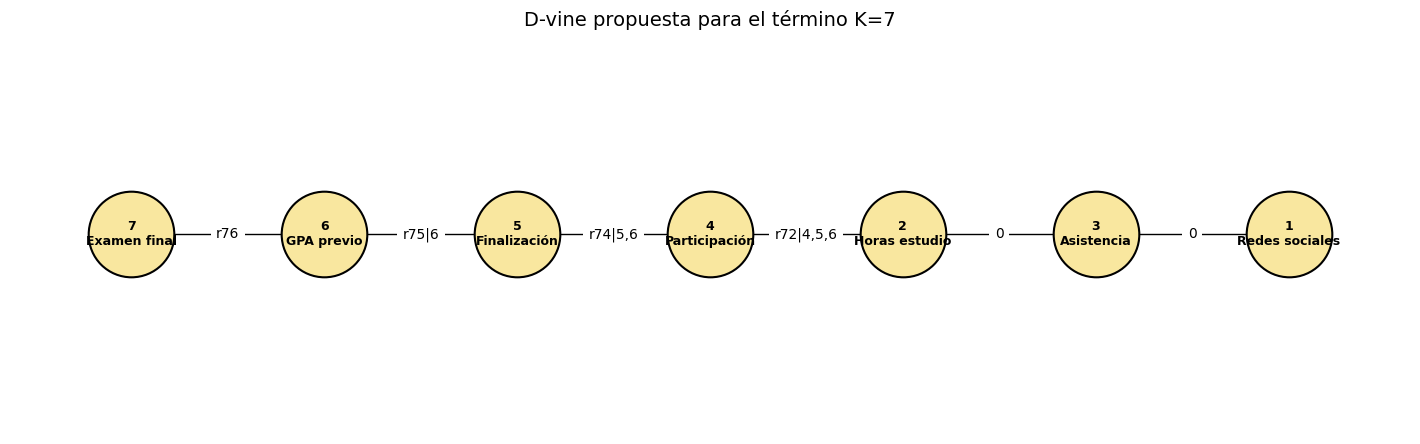

In [43]:
import matplotlib.pyplot as plt
import networkx as nx

# D-vine para K = 7
vine_edges = [
    ("7", "6"),
    ("6", "5"),
    ("5", "4"),
    ("4", "2"),
    ("2", "3"),
    ("3", "1")
]

G_vine = nx.Graph()
G_vine.add_edges_from(vine_edges)

pos_vine = {
    "7": (0, 0),
    "6": (1.5, 0),
    "5": (3, 0),
    "4": (4.5, 0),
    "2": (6, 0),
    "3": (7.5, 0),
    "1": (9, 0)
}

labels_vine = {
    "7": "7\nExamen final",
    "6": "6\nGPA previo",
    "5": "5\nFinalización",
    "4": "4\nParticipación",
    "2": "2\nHoras estudio",
    "3": "3\nAsistencia",
    "1": "1\nRedes sociales"
}

edge_labels_vine = {
    ("7", "6"): "r76",
    ("6", "5"): "r75|6",
    ("5", "4"): "r74|5,6",
    ("4", "2"): "r72|4,5,6",
    ("2", "3"): "0",
    ("3", "1"): "0"
}

plt.figure(figsize=(14, 4))

nx.draw(
    G_vine, pos_vine,
    with_labels=False,
    node_size=3800,
    node_color="#F9E79F",
    edgecolors="black",
    linewidths=1.5
)

nx.draw_networkx_labels(G_vine, pos_vine, labels=labels_vine, font_size=9, font_weight="bold")
nx.draw_networkx_edge_labels(
    G_vine, pos_vine,
    edge_labels=edge_labels_vine,
    font_size=10,
    bbox=dict(facecolor="white", edgecolor="none")
)

plt.title("D-vine propuesta para el término K=7", fontsize=14)
plt.axis("off")
plt.show()

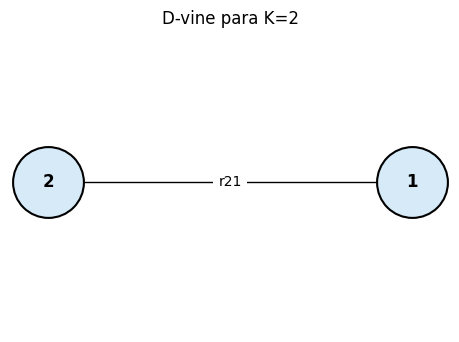

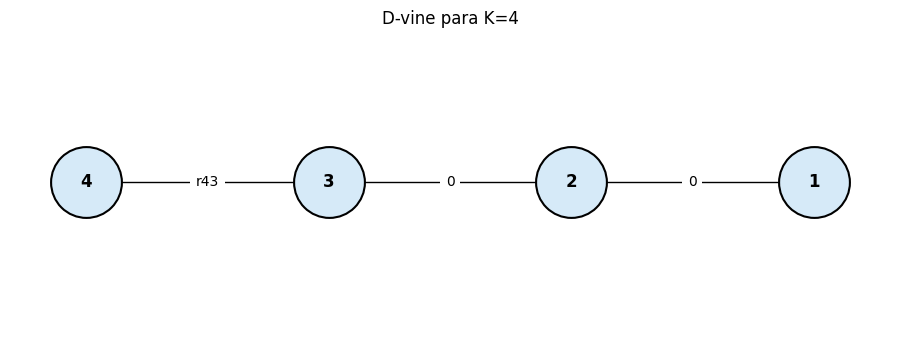

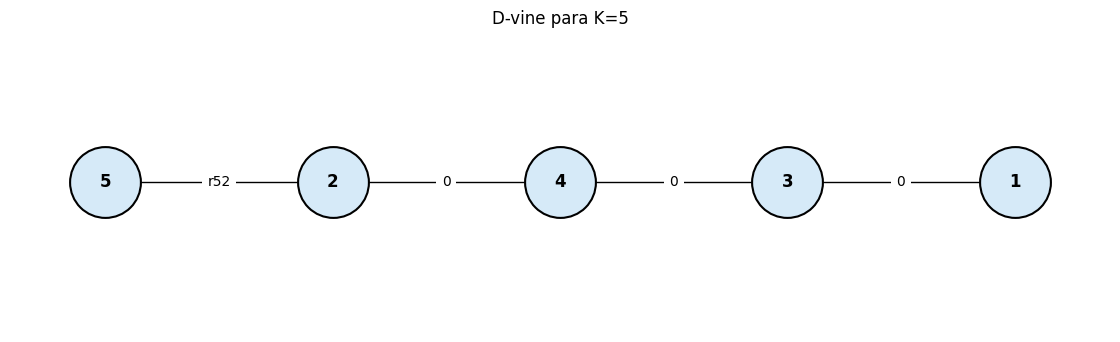

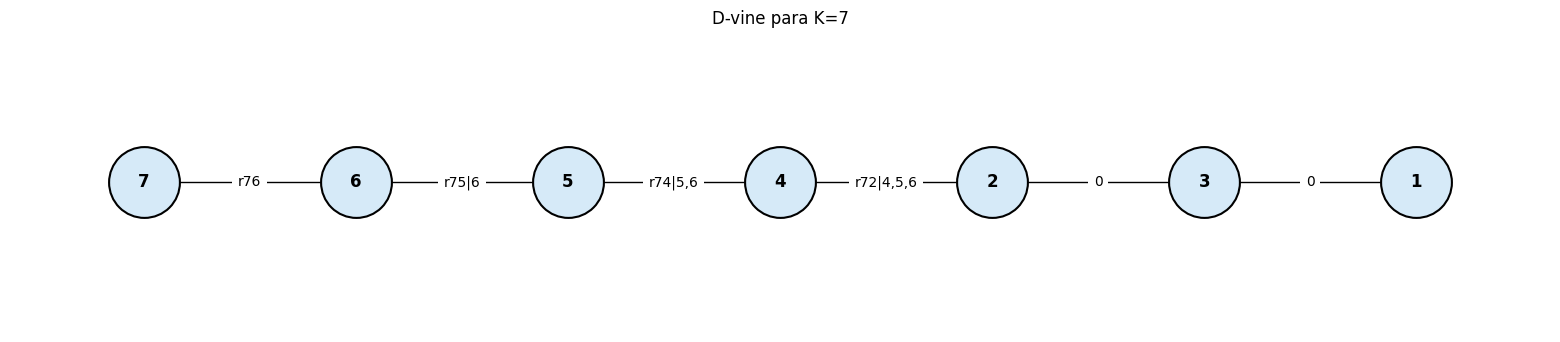

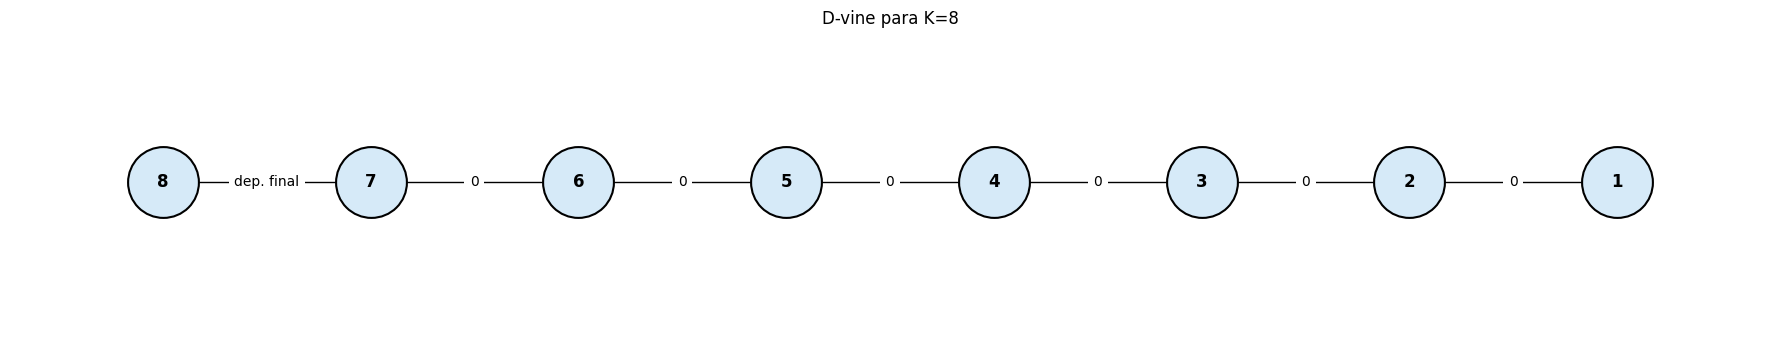

In [44]:
def draw_simple_vine(nodes, edge_labels_dict, title):
    G = nx.Graph()
    edges = [(nodes[i], nodes[i+1]) for i in range(len(nodes)-1)]
    G.add_edges_from(edges)

    pos = {node: (i * 2, 0) for i, node in enumerate(nodes)}

    plt.figure(figsize=(2.2 * len(nodes), 3))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=2600,
        node_color="#D6EAF8",
        edgecolors="black",
        linewidths=1.5,
        font_weight="bold"
    )
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels_dict,
        font_size=10,
        bbox=dict(facecolor="white", edgecolor="none")
    )
    plt.title(title)
    plt.axis("off")
    plt.show()

# K = 2
draw_simple_vine(
    ["2", "1"],
    {("2", "1"): "r21"},
    "D-vine para K=2"
)

# K = 4
draw_simple_vine(
    ["4", "3", "2", "1"],
    {("4", "3"): "r43", ("3", "2"): "0", ("2", "1"): "0"},
    "D-vine para K=4"
)

# K = 5
draw_simple_vine(
    ["5", "2", "4", "3", "1"],
    {("5", "2"): "r52", ("2", "4"): "0", ("4", "3"): "0", ("3", "1"): "0"},
    "D-vine para K=5"
)

# K = 7
draw_simple_vine(
    ["7", "6", "5", "4", "2", "3", "1"],
    {
        ("7", "6"): "r76",
        ("6", "5"): "r75|6",
        ("5", "4"): "r74|5,6",
        ("4", "2"): "r72|4,5,6",
        ("2", "3"): "0",
        ("3", "1"): "0"
    },
    "D-vine para K=7"
)

# K = 8
draw_simple_vine(
    ["8", "7", "6", "5", "4", "3", "2", "1"],
    {
        ("8", "7"): "dep. final",
        ("7", "6"): "0",
        ("6", "5"): "0",
        ("5", "4"): "0",
        ("4", "3"): "0",
        ("3", "2"): "0",
        ("2", "1"): "0"
    },
    "D-vine para K=8"
)

In [45]:
tabla_protocolo = pd.DataFrame({
    "K": [2, 4, 5, 7, 8],
    "Variable": [
        "horas_de_estudio_por_dia",
        "puntuacion_participacion",
        "tasa_de_finalizacion_asignacion",
        "puntuacion_examen_final",
        "pass_fail"
    ],
    "CK": [
        "{1}",
        "{3}",
        "{2}",
        "{2,4,5,6}",
        "{7}"
    ],
    "IK": [
        "{}",
        "{1,2}",
        "{1,3,4}",
        "{1,3}",
        "{1,2,3,4,5,6}"
    ],
    "D-vine propuesta": [
        "D(2,1)",
        "D(4,3,2,1)",
        "D(5,2,4,3,1)",
        "D(7,6,5,4,2,3,1)",
        "D(8,7,6,5,4,3,2,1)"
    ]
})

tabla_protocolo

,K,Variable,CK,IK,D-vine propuesta
0,2,horas_de_estudio_por_dia,{1},{},"D(2,1)"
1,4,puntuacion_participacion,{3},"{1,2}","D(4,3,2,1)"
2,5,tasa_de_finalizacion_asignacion,{2},"{1,3,4}","D(5,2,4,3,1)"
3,7,puntuacion_examen_final,"{2,4,5,6}","{1,3}","D(7,6,5,4,2,3,1)"
4,8,pass_fail,{7},"{1,2,3,4,5,6}","D(8,7,6,5,4,3,2,1)"


In [46]:
correlaciones_posibles = [
    "r21",
    "r43",
    "r52",
    "r76",
    "r75|6",
    "r74|5,6",
    "r72|4,5,6",
    "r71|2,4,5,6",
    "r73|2,4,5,6",
    "r87"
]

tabla_correlaciones_posibles = pd.DataFrame({
    "correlacion": correlaciones_posibles,
    "usar_en_modelo": ["Si", "Si", "Si", "Si", "Si", "Si", "Si", "No", "No", "Si"],
    "comentario": [
        "Dependencia principal 2-1",
        "Dependencia principal 4-3",
        "Dependencia principal 5-2",
        "Dependencia principal 7-6",
        "Dependencia condicional",
        "Dependencia condicional",
        "Dependencia condicional",
        "Variable 1 independiente dado CK",
        "Variable 3 independiente dado CK",
        "Nodo final discreto"
    ]
})

tabla_correlaciones_posibles

,correlacion,usar_en_modelo,comentario
0,r21,Si,Dependencia principal 2-1
1,r43,Si,Dependencia principal 4-3
2,r52,Si,Dependencia principal 5-2
3,r76,Si,Dependencia principal 7-6
4,r75|6,Si,Dependencia condicional
5,"r74|5,6",Si,Dependencia condicional
6,"r72|4,5,6",Si,Dependencia condicional
7,"r71|2,4,5,6",No,Variable 1 independiente dado CK
8,"r73|2,4,5,6",No,Variable 3 independiente dado CK
9,r87,Si,Nodo final discreto


In [47]:
correlaciones_elegidas = pd.DataFrame({
    "correlacion": ["r21", "r43", "r52", "r76", "r75|6", "r74|5,6", "r72|4,5,6", "r87"],
    "tipo": [
        "No condicional",
        "No condicional",
        "No condicional",
        "No condicional",
        "Condicional",
        "Condicional",
        "Condicional",
        "Dependencia final"
    ]
})

correlaciones_elegidas

,correlacion,tipo
0,r21,No condicional
1,r43,No condicional
2,r52,No condicional
3,r76,No condicional
4,r75|6,Condicional
5,"r74|5,6",Condicional
6,"r72|4,5,6",Condicional
7,r87,Dependencia final


In [49]:
from scipy.stats import norm

z_df = uniform_df.copy()
for col in z_df.columns:
    z_df[col] = norm.ppf(np.clip(z_df[col], 1e-6, 1 - 1e-6))

z_df.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
0,-1.428618,-0.064821,0.523501,-0.085288,-0.416873,0.798210,-0.071279
1,0.475503,1.182387,0.418087,1.548766,-0.726359,1.431245,1.646792
2,0.290013,0.588479,-0.814224,-1.650971,-0.516577,-0.920028,-0.635788
3,0.687285,-0.870840,-0.955156,0.201868,-0.938288,-1.191328,-1.478461
4,0.171717,1.767811,-0.258683,-0.974104,-0.699435,1.087597,1.344085


In [50]:
z_df.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_redes_sociales,2500.0,1.053643e-01,1.051834,-3.677050,-0.141187,0.290013,0.652446,3.160021
horas_de_estudio_por_dia,2500.0,1.136868e-17,1.000200,-2.168954,-0.684183,-0.005430,0.692413,3.549537
tasa_asistencia,2500.0,-1.158922e-01,1.064307,-1.733678,-0.705161,-0.383005,0.013687,3.288136
puntuacion_participacion,2500.0,9.407586e-16,1.000200,-3.175632,-0.666437,0.007012,0.694135,2.054707
tasa_de_finalizacion_asignacion,2500.0,-1.235731e-01,1.075908,-1.584217,-0.752980,-0.423980,0.003147,2.772782
anterior_gpa,2500.0,-2.145839e-16,1.000200,-3.614947,-0.689422,0.002395,0.671603,3.384609
puntuacion_examen_final,2500.0,-1.712408e-16,1.000200,-3.433789,-0.652150,-0.014010,0.665037,3.593940


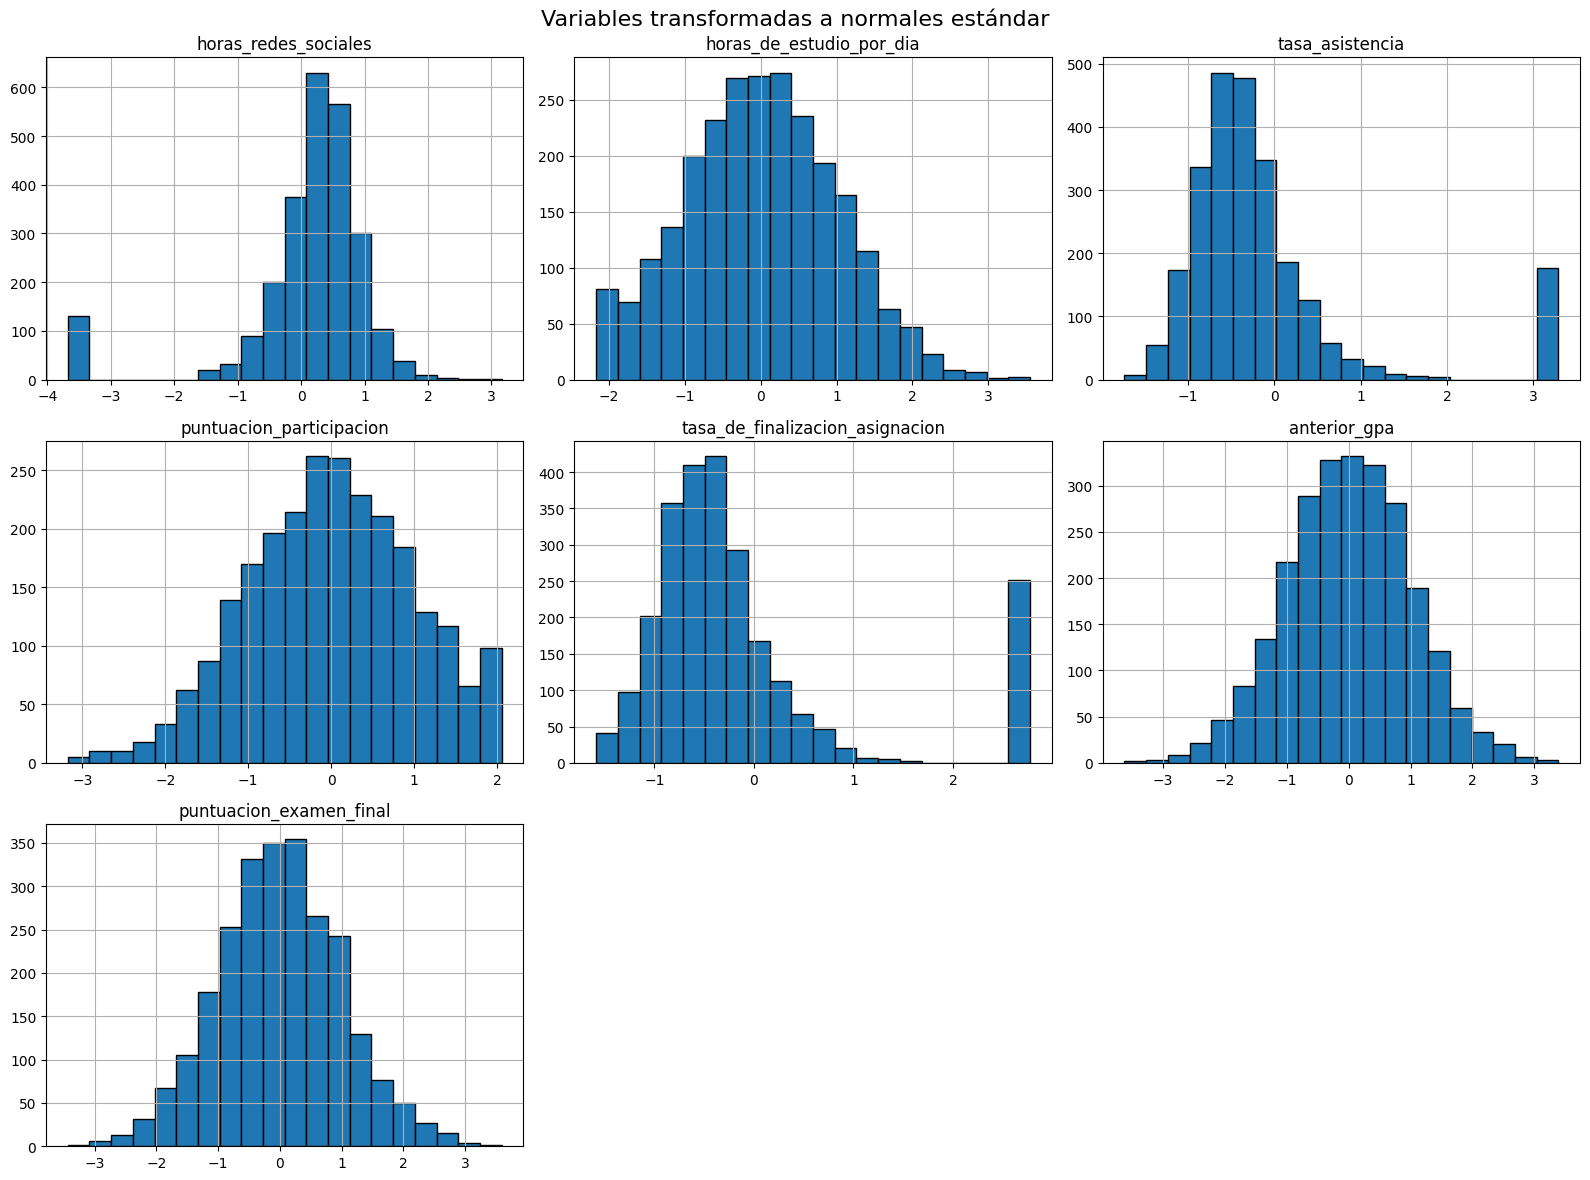

In [51]:
z_df.hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Variables transformadas a normales estándar", fontsize=16)
plt.tight_layout()
plt.show()

In [52]:
medianas = df_modelo[variables_continuas].median()
medianas

,0
horas_redes_sociales,2.40
horas_de_estudio_por_dia,3.05
tasa_asistencia,85.10
puntuacion_participacion,70.05
tasa_de_finalizacion_asignacion,80.30
anterior_gpa,2.00
puntuacion_examen_final,49.80


In [53]:
def prob_mediana_condicional(df, x, y):
    mx = df[x].median()
    my = df[y].median()

    cond = df[y] >= my
    if cond.sum() == 0:
        return np.nan

    prob = (df.loc[cond, x] >= mx).mean()
    return prob

preguntas_base = [
    ("horas_de_estudio_por_dia", "horas_redes_sociales"),
    ("puntuacion_participacion", "tasa_asistencia"),
    ("tasa_de_finalizacion_asignacion", "horas_de_estudio_por_dia"),
    ("puntuacion_examen_final", "anterior_gpa"),
    ("puntuacion_examen_final", "tasa_de_finalizacion_asignacion"),
    ("puntuacion_examen_final", "puntuacion_participacion"),
    ("puntuacion_examen_final", "horas_de_estudio_por_dia")
]

res_preguntas = []
for x, y in preguntas_base:
    p = prob_mediana_condicional(df_modelo, x, y)
    res_preguntas.append({
        "pregunta": f"P({x} >= mediana | {y} >= mediana)",
        "valor_empirico": p
    })

tabla_preguntas = pd.DataFrame(res_preguntas)
tabla_preguntas

,pregunta,valor_empirico
0,P(horas_de_estudio_por_dia >= mediana | horas_...,0.497706
1,P(puntuacion_participacion >= mediana | tasa_a...,0.500000
2,P(tasa_de_finalizacion_asignacion >= mediana |...,0.488854
3,P(puntuacion_examen_final >= mediana | anterio...,0.829249
4,P(puntuacion_examen_final >= mediana | tasa_de...,0.568690
5,P(puntuacion_examen_final >= mediana | puntuac...,0.555200
6,P(puntuacion_examen_final >= mediana | horas_d...,0.700637


In [54]:
cuestionario = []
for x, y in preguntas_base:
    cuestionario.append(f"¿Cuál es la probabilidad de que {x} sea mayor o igual a su mediana dado que {y} es mayor o igual a su mediana?")

for i, q in enumerate(cuestionario, 1):
    print(f"{i}. {q}")

1. ¿Cuál es la probabilidad de que horas_de_estudio_por_dia sea mayor o igual a su mediana dado que horas_redes_sociales es mayor o igual a su mediana?
2. ¿Cuál es la probabilidad de que puntuacion_participacion sea mayor o igual a su mediana dado que tasa_asistencia es mayor o igual a su mediana?
3. ¿Cuál es la probabilidad de que tasa_de_finalizacion_asignacion sea mayor o igual a su mediana dado que horas_de_estudio_por_dia es mayor o igual a su mediana?
4. ¿Cuál es la probabilidad de que puntuacion_examen_final sea mayor o igual a su mediana dado que anterior_gpa es mayor o igual a su mediana?
5. ¿Cuál es la probabilidad de que puntuacion_examen_final sea mayor o igual a su mediana dado que tasa_de_finalizacion_asignacion es mayor o igual a su mediana?
6. ¿Cuál es la probabilidad de que puntuacion_examen_final sea mayor o igual a su mediana dado que puntuacion_participacion es mayor o igual a su mediana?
7. ¿Cuál es la probabilidad de que puntuacion_examen_final sea mayor o igual a

In [55]:
matriz_pearson_z = z_df.corr(method="pearson")
matriz_pearson_z

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
horas_redes_sociales,1.000000,-0.012483,0.013513,0.024561,-0.043227,-0.195522,-0.216601
horas_de_estudio_por_dia,-0.012483,1.000000,0.012756,0.032222,-0.029037,0.528662,0.585689
tasa_asistencia,0.013513,0.012756,1.000000,0.012412,-0.003153,0.100458,0.114857
puntuacion_participacion,0.024561,0.032222,0.012412,1.000000,-0.027704,0.128333,0.154211
tasa_de_finalizacion_asignacion,-0.043227,-0.029037,-0.003153,-0.027704,1.000000,0.133360,0.145934
anterior_gpa,-0.195522,0.528662,0.100458,0.128333,0.133360,1.000000,0.890266
puntuacion_examen_final,-0.216601,0.585689,0.114857,0.154211,0.145934,0.890266,1.000000


In [56]:
tabla_interpretacion = tabla_rangos.copy()

def clasificar_fuerza(x):
    ax = abs(x)
    if ax < 0.05:
        return "prácticamente nula"
    elif ax < 0.15:
        return "débil"
    elif ax < 0.35:
        return "moderada"
    elif ax < 0.60:
        return "moderada-alta"
    else:
        return "alta"

tabla_interpretacion["fuerza"] = tabla_interpretacion["valor"].apply(clasificar_fuerza)
tabla_interpretacion

,correlacion,valor,fuerza
0,r21,-0.008789,prácticamente nula
1,r43,0.014816,prácticamente nula
2,r52,-0.026083,prácticamente nula
3,r76,0.882865,alta
4,r75|6,0.091583,débil
5,"r74|5,6",0.102055,débil
6,"r72|4,5,6",0.329356,moderada


In [57]:
import numpy as np
import pandas as pd

np.random.seed(123)

# matriz de correlación sobre z
R = matriz_pearson_z.values

# asegurar simetría
R = (R + R.T) / 2

# pequeña corrección numérica
eigvals = np.linalg.eigvals(R)
print("Autovalores:", eigvals)

sim_z = np.random.multivariate_normal(
    mean=np.zeros(R.shape[0]),
    cov=R,
    size=5000
)

sim_z_df = pd.DataFrame(sim_z, columns=z_df.columns)
sim_z_df.head()

Autovalores: [2.45175431 0.10462788 0.45402088 1.07717755 0.94502644 0.99754789
 0.96984506]


,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
0,-0.547448,-1.440662,-0.367089,-1.858426,-0.872165,0.030628,-1.298802
1,-0.352400,-1.326781,0.480074,-1.428906,0.401935,0.217704,-0.262717
2,1.000397,-0.368220,-2.646489,1.639059,0.455392,-0.445155,-0.153295
3,-0.400981,1.292300,-0.379006,-0.058813,-1.733882,1.942492,1.228746
4,-0.969953,0.699379,1.335730,-1.223830,-2.592878,-0.586352,-0.092943


In [59]:
corr_sim = sim_z_df.corr(method="pearson")

comparacion_corr = pd.DataFrame({
    "original": matriz_pearson_z.stack().values,
    "simulada": corr_sim.stack().values
})

comparacion_corr.head(15)

,original,simulada
0,1.000000,1.000000
1,-0.012483,-0.001971
2,0.013513,0.023052
3,0.024561,0.053918
4,-0.043227,-0.028134
5,-0.195522,-0.194318
6,-0.216601,-0.224320
7,-0.012483,-0.001971
8,1.000000,1.000000
9,0.012756,0.013128


In [60]:
print("Correlación observada examen_final - anterior_gpa:",
      matriz_pearson_z.loc["puntuacion_examen_final", "anterior_gpa"])
print("Correlación simulada examen_final - anterior_gpa:",
      corr_sim.loc["puntuacion_examen_final", "anterior_gpa"])

print("Correlación observada examen_final - horas_estudio:",
      matriz_pearson_z.loc["puntuacion_examen_final", "horas_de_estudio_por_dia"])
print("Correlación simulada examen_final - horas_estudio:",
      corr_sim.loc["puntuacion_examen_final", "horas_de_estudio_por_dia"])

Correlación observada examen_final - anterior_gpa: 0.8902655650360347
Correlación simulada examen_final - anterior_gpa: 0.8941857806930401
Correlación observada examen_final - horas_estudio: 0.5856891012502145
Correlación simulada examen_final - horas_estudio: 0.5744948178230439


In [61]:
from scipy.stats import norm

sim_u_df = sim_z_df.copy()
for col in sim_u_df.columns:
    sim_u_df[col] = norm.cdf(sim_u_df[col])

sim_u_df.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
0,0.292035,0.074840,0.356776,0.031554,0.191559,0.512217,0.097006
1,0.362269,0.092291,0.684412,0.076516,0.656134,0.586170,0.396384
2,0.841441,0.356355,0.004067,0.949400,0.675586,0.328104,0.439083
3,0.344217,0.901873,0.352342,0.476550,0.041470,0.973961,0.890417
4,0.166035,0.757842,0.909181,0.110508,0.004759,0.278820,0.462975


In [62]:
def from_uniform(u, row):
    u = np.clip(np.asarray(u), 1e-6, 1 - 1e-6)
    var = row["variable"]

    if row["mejor_distribucion"] == "normal":
        x = stats.norm.ppf(u, loc=row["param_1"], scale=row["param_2"])

    elif row["mejor_distribucion"] == "gamma":
        x = stats.gamma.ppf(u, a=row["param_1"], loc=0, scale=row["param_2"])

    elif row["mejor_distribucion"] == "beta_escalada":
        lower, upper = bounds[var]
        y = stats.beta.ppf(u, a=row["param_1"], b=row["param_2"], loc=0, scale=1)
        x = lower + y * (upper - lower)

    else:
        raise ValueError("Distribución no soportada")

    return x

In [63]:
sim_original_df = pd.DataFrame()

for _, row in tabla_marginales.iterrows():
    var = row["variable"]
    sim_original_df[var] = from_uniform(sim_u_df[var], row)

sim_original_df.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final
0,0.729628,1.358389,85.392917,42.765729,65.860914,2.015610,34.095972
1,1.016529,1.492613,96.185112,49.047978,95.897065,2.119043,46.760048
2,4.399417,2.622405,28.736383,93.920647,96.403951,1.752553,48.097517
3,0.939062,4.579547,85.173904,69.087222,34.941768,3.072665,64.990217
4,0.312625,3.880711,99.525815,52.047457,13.060616,1.674487,48.835201


In [64]:
sim_original_df["pass_fail"] = np.where(
    sim_original_df["puntuacion_examen_final"] >= 50,
    "Pass",
    "Fail"
)

sim_original_df.head()

,horas_redes_sociales,horas_de_estudio_por_dia,tasa_asistencia,puntuacion_participacion,tasa_de_finalizacion_asignacion,anterior_gpa,puntuacion_examen_final,pass_fail
0,0.729628,1.358389,85.392917,42.765729,65.860914,2.015610,34.095972,Fail
1,1.016529,1.492613,96.185112,49.047978,95.897065,2.119043,46.760048,Fail
2,4.399417,2.622405,28.736383,93.920647,96.403951,1.752553,48.097517,Fail
3,0.939062,4.579547,85.173904,69.087222,34.941768,3.072665,64.990217,Pass
4,0.312625,3.880711,99.525815,52.047457,13.060616,1.674487,48.835201,Fail


In [65]:
comparacion_resumen = []

for col in variables_continuas:
    comparacion_resumen.append({
        "variable": col,
        "media_original": df_modelo[col].mean(),
        "media_simulada": sim_original_df[col].mean(),
        "mediana_original": df_modelo[col].median(),
        "mediana_simulada": sim_original_df[col].median(),
        "q90_original": df_modelo[col].quantile(0.90),
        "q90_simulada": sim_original_df[col].quantile(0.90),
    })

tabla_comparacion = pd.DataFrame(comparacion_resumen)
tabla_comparacion

,variable,media_original,media_simulada,mediana_original,mediana_simulada,q90_original,q90_simulada
0,horas_redes_sociales,2.478160,2.227557,2.40,1.707991,4.40,5.234979
1,horas_de_estudio_por_dia,3.056400,3.092528,3.05,3.109286,4.58,4.569947
2,tasa_asistencia,84.766160,86.138334,85.10,91.113606,97.80,99.409070
3,puntuacion_participacion,69.947440,69.896236,70.05,70.061477,89.50,88.648135
4,tasa_de_finalizacion_asignacion,79.586840,82.251295,80.30,90.265193,100.00,99.758737
5,anterior_gpa,1.998676,2.013512,2.00,2.027453,2.70,2.716066
6,puntuacion_examen_final,49.971240,50.401784,49.80,50.569936,65.30,66.307866


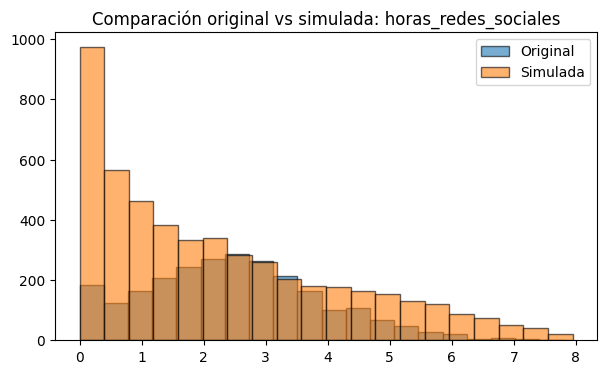

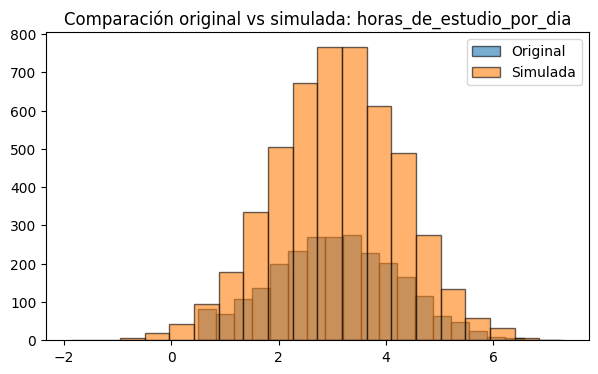

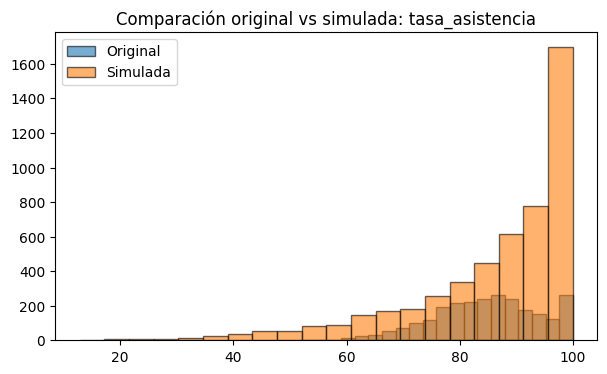

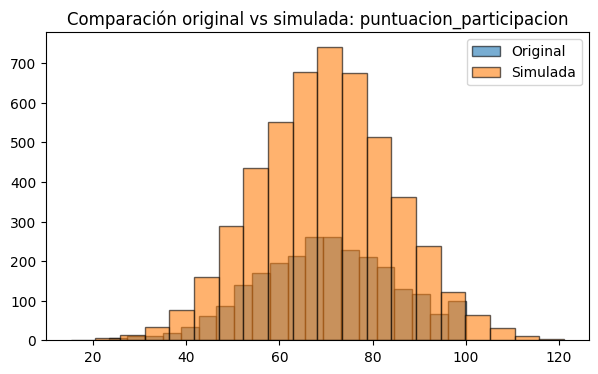

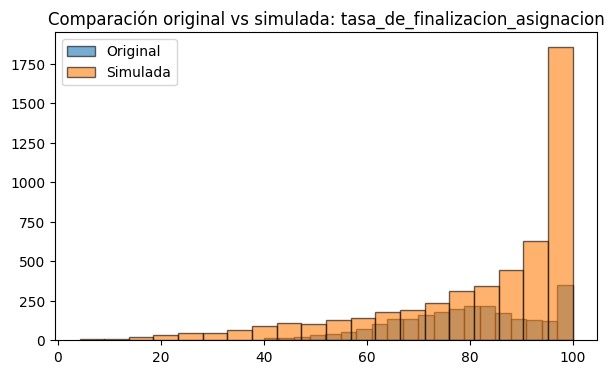

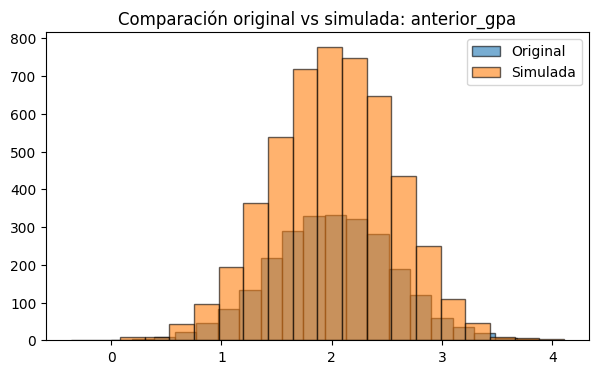

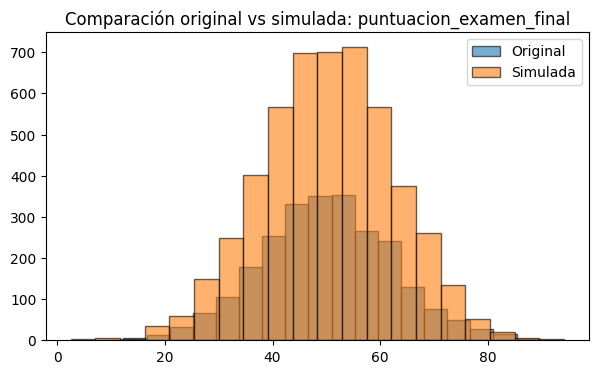

In [66]:
for col in variables_continuas:
    plt.figure(figsize=(7,4))
    plt.hist(df_modelo[col], bins=20, alpha=0.6, label="Original", edgecolor="black")
    plt.hist(sim_original_df[col], bins=20, alpha=0.6, label="Simulada", edgecolor="black")
    plt.title(f"Comparación original vs simulada: {col}")
    plt.legend()
    plt.show()

In [70]:
edges_final = [
    ("anterior_gpa", "puntuacion_examen_final"),
    ("horas_de_estudio_por_dia", "puntuacion_examen_final"),
    ("puntuacion_participacion", "puntuacion_examen_final"),
    ("tasa_de_finalizacion_asignacion", "puntuacion_examen_final"),
    ("puntuacion_examen_final", "pass_fail")
]


In [71]:
hallazgos = pd.DataFrame({
    "Relacion": [
        "horas_redes_sociales -> horas_de_estudio_por_dia",
        "tasa_asistencia -> puntuacion_participacion",
        "horas_de_estudio_por_dia -> tasa_de_finalizacion_asignacion",
        "anterior_gpa -> puntuacion_examen_final",
        "tasa_de_finalizacion_asignacion -> puntuacion_examen_final",
        "puntuacion_participacion -> puntuacion_examen_final",
        "horas_de_estudio_por_dia -> puntuacion_examen_final",
        "puntuacion_examen_final -> pass_fail"
    ],
    "Indicador": [
        "r21",
        "r43",
        "r52",
        "r76",
        "r75|6",
        "r74|5,6",
        "r72|4,5,6",
        "r87"
    ],
    "Valor": [
        -0.008789,
        0.014816,
        -0.026083,
        0.882865,
        0.091583,
        0.102055,
        0.329356,
        np.nan
    ],
    "Interpretacion": [
        "Prácticamente nula",
        "Prácticamente nula",
        "Prácticamente nula",
        "Alta",
        "Débil",
        "Débil",
        "Moderada",
        "Dependencia casi determinista"
    ]
})

hallazgos

,Relacion,Indicador,Valor,Interpretacion
0,horas_redes_sociales -> horas_de_estudio_por_dia,r21,-0.008789,Prácticamente nula
1,tasa_asistencia -> puntuacion_participacion,r43,0.014816,Prácticamente nula
2,horas_de_estudio_por_dia -> tasa_de_finalizaci...,r52,-0.026083,Prácticamente nula
3,anterior_gpa -> puntuacion_examen_final,r76,0.882865,Alta
4,tasa_de_finalizacion_asignacion -> puntuacion_...,r75|6,0.091583,Débil
5,puntuacion_participacion -> puntuacion_examen_...,"r74|5,6",0.102055,Débil
6,horas_de_estudio_por_dia -> puntuacion_examen_...,"r72|4,5,6",0.329356,Moderada
7,puntuacion_examen_final -> pass_fail,r87,NaN,Dependencia casi determinista
